<div style="background:linear-gradient(135deg,#0f2027,#203a43,#2c5364);padding:28px;border-radius:12px;color:white;text-align:center;font-family:'Segoe UI',sans-serif;">
<h1 style="margin:0 0 8px 0;">Análise Preditiva (N3) — versão executada</h1>
<h2 style="margin:0 0 16px 0;font-weight:300;">Séries Temporais — PETR4 (B3) 2025</h2>
<p><b>Grupo:</b> Higor, Nathan, Nicolas &middot; <b>Ticker:</b> PETR4 &middot; <b>Horizonte:</b> 14 pregões &middot; <b>Tracking:</b> Weights &amp; Biases (offline)</p>
</div>

## Descrição do case
Pipeline de análise preditiva sobre o **fechamento diário da PETR4** (Petrobras PN, B3) em 2025, a partir do `cotahist_2025_tratado.csv`. Cobre auditoria/limpeza, engenharia de atributos, *baselines*, estacionariedade, **três famílias de modelos** (SARIMAX/SARIMAX-X, Holt, Gradient Boosting), *walk-forward*, previsão com IC 95% e rastreio de experimentos no **wandb**.

> **Correção de qualidade de dados importante:** no arquivo bruto o ticker `PETR4` agrega **múltiplos segmentos de mercado** sem coluna de distinção — para a mesma data convivem fechamentos de ~R\$37 (à vista) e ~R\$43 (outro segmento). Um `groupby('data').last()` ingênuo escolheria um segmento arbitrário por dia, injetando *spikes* falsos. Aqui isolamos o **lote-padrão (à vista)** e agregamos por dia, obtendo uma série coerente (R\$29–38) que reproduz inclusive o tombo real de abril/2025.

## 0. Setup, helpers e parâmetros

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
N3 - Pipeline corrigido: PETR4 (B3) 2025.
- Serie diaria limpa (round-lot), corrige a conflacao de segmentos sob o ticker PETR4.
- Conecta features aos modelos: SARIMAX-X (exogenas ciclicas) e LSTM multivariado.
- Gera figuras, tabelas e logs no Weights & Biases (online com login seguro; offline+sync como fallback).
"""
import os, json, warnings, math, random
import numpy as np, pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import scipy.stats as stats

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import GradientBoostingRegressor
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing, Holt
from statsmodels.stats.diagnostic import acorr_ljungbox

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (14, 5); plt.rcParams["axes.grid"] = True
SEED = 42; random.seed(SEED); np.random.seed(SEED)

OUT = os.getcwd()
FIG = os.path.join(OUT, "figs"); os.makedirs(FIG, exist_ok=True)
HORIZON = 14; TEST_FRAC = 0.20
R = {}  # resultados

def mae(y, yh):  return float(mean_absolute_error(y, yh))
def rmse(y, yh): return float(np.sqrt(mean_squared_error(y, yh)))
def mape(y, yh):
    y = np.asarray(y, float); yh = np.asarray(yh, float)
    return float(np.mean(np.abs((y - yh) / np.where(y == 0, np.nan, y))) * 100)

## 1. Serie limpa

In [2]:
# ---------- 1. Serie limpa ----------
s = pd.read_csv(os.path.join(OUT, "petr4_daily_clean.csv"), index_col=0, parse_dates=True).iloc[:, 0]
s.index.name = "data"; s.name = "fechamento"
print(f"[1] Serie: {len(s)} dias | {s.index.min().date()} -> {s.index.max().date()} | R$ {s.min():.2f}-{s.max():.2f}", flush=True)
R["serie"] = {"n": int(len(s)), "ini": str(s.index.min().date()), "fim": str(s.index.max().date()),
              "min": round(float(s.min()),2), "max": round(float(s.max()),2)}

fig, ax = plt.subplots(figsize=(14,5)); ax.plot(s.index, s.values, color="#1f77b4", lw=1.3)
ax.set_title("PETR4 - Fechamento diario (round-lot, 2025-H1)"); ax.set_ylabel("R$")
plt.tight_layout(); plt.savefig(f"{FIG}/fig_serie.png", dpi=110); plt.close()

[1] Serie: 128 dias | 2025-01-02 -> 2025-06-30 | R$ 29.18-38.48


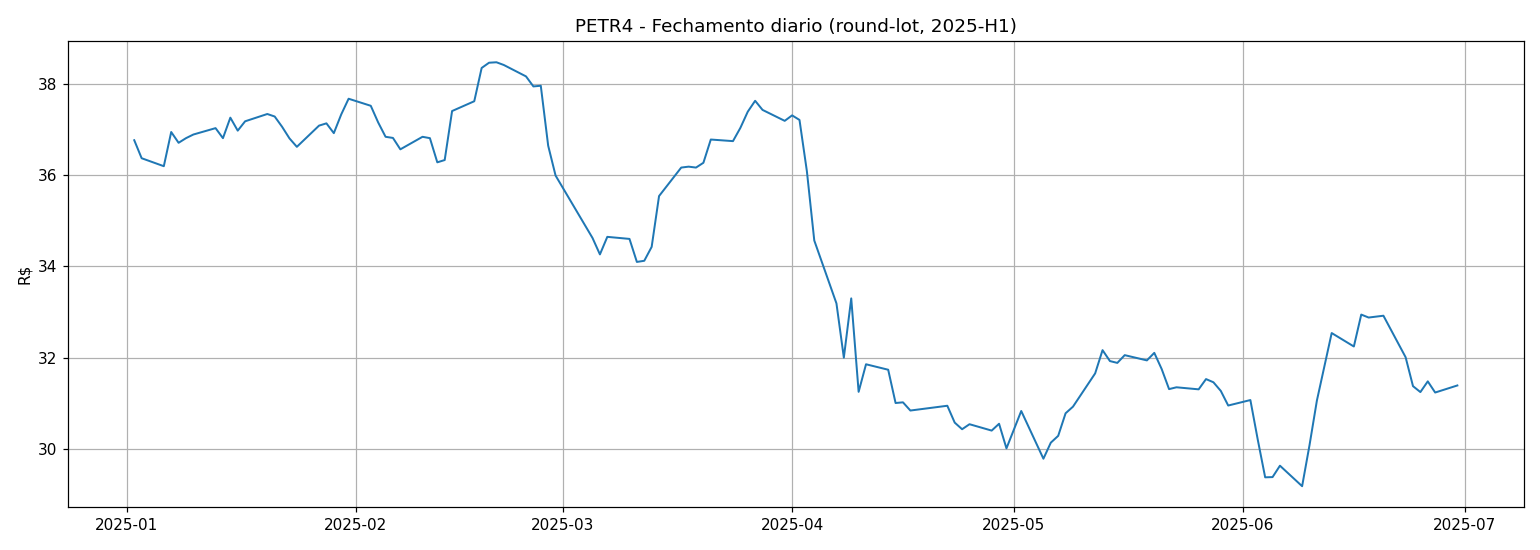

**Série limpa.** 128 pregões (2025-01-02 → 2025-06-30), faixa R\$29.18–38.48. O nível recua de ~R\$37 (jan) para ~R\$31 (jun), com o forte tombo de **abril/2025** (choque tarifário global) bem visível — sinal de que a série capta dinâmica real do ativo.

## 2. Feature engineering

In [3]:
# ---------- 2. Feature engineering ----------
feat = s.to_frame()
for k in [1,2,5]: feat[f"lag{k}"] = feat["fechamento"].shift(k)
feat["mm7"]  = feat["fechamento"].shift(1).rolling(7).mean()
feat["mm21"] = feat["fechamento"].shift(1).rolling(21).mean()
mes = feat.index.month; dow = feat.index.dayofweek
feat["mes_sin"] = np.sin(2*np.pi*mes/12); feat["mes_cos"] = np.cos(2*np.pi*mes/12)
feat["dow_sin"] = np.sin(2*np.pi*dow/5);  feat["dow_cos"] = np.cos(2*np.pi*dow/5)
feat = feat.dropna()
n_tr = int(len(feat)*(1-TEST_FRAC))
tr, te = feat.iloc[:n_tr], feat.iloc[n_tr:]
y_tr, y_te = tr["fechamento"], te["fechamento"]
EXOG = ["mes_sin","mes_cos","dow_sin","dow_cos"]
print(f"[2] Dataset features: {feat.shape} | treino {len(tr)} / teste {len(te)}", flush=True)
R["split"] = {"features": list(feat.columns), "n_treino": int(len(tr)), "n_teste": int(len(te))}

[2] Dataset features: (107, 10) | treino 85 / teste 22


## 3. Baselines

In [4]:
# ---------- 3. Baselines ----------
yh_naive = te["lag1"]; yh_mm7 = te["mm7"]
R["baselines"] = {
 "Persistencia": {"MAE":mae(y_te,yh_naive),"RMSE":rmse(y_te,yh_naive),"MAPE":mape(y_te,yh_naive)},
 "MediaMovel7":  {"MAE":mae(y_te,yh_mm7),  "RMSE":rmse(y_te,yh_mm7),  "MAPE":mape(y_te,yh_mm7)}}
print("[3] Baselines OK", flush=True)

[3] Baselines OK


## 4. Estacionariedade

In [5]:
# ---------- 4. Estacionariedade ----------
adf0 = adfuller(y_tr.dropna());
try: kp0 = kpss(y_tr.dropna(), regression="c", nlags="auto")
except Exception: kp0 = (np.nan,np.nan)
yd = y_tr.diff().dropna(); adf1 = adfuller(yd)
R["estacionariedade"] = {"adf_orig_p": round(float(adf0[1]),4), "kpss_orig_p": round(float(kp0[1]),4),
                         "adf_diff_p": round(float(adf1[1]),4)}
print(f"[4] ADF orig p={adf0[1]:.4f} | ADF diff p={adf1[1]:.4f}", flush=True)

stl = STL(y_tr, period=21, robust=True).fit()
fig, ax = plt.subplots(4,1,figsize=(14,10),sharex=True)
ax[0].plot(y_tr); ax[0].set_title("Serie (treino)"); ax[1].plot(stl.trend); ax[1].set_title("Tendencia")
ax[2].plot(stl.seasonal); ax[2].set_title("Sazonalidade (p=21)"); ax[3].plot(stl.resid); ax[3].set_title("Residuo")
plt.tight_layout(); plt.savefig(f"{FIG}/fig_decomp.png", dpi=110); plt.close()
fig, ax = plt.subplots(1,2,figsize=(14,4))
plot_acf(yd, lags=20, ax=ax[0]); ax[0].set_title("ACF (1a dif)")
plot_pacf(yd, lags=20, ax=ax[1], method="ywm"); ax[1].set_title("PACF (1a dif)")
plt.tight_layout(); plt.savefig(f"{FIG}/fig_acf_pacf.png", dpi=110); plt.close()

[4] ADF orig p=0.5841 | ADF diff p=0.0001


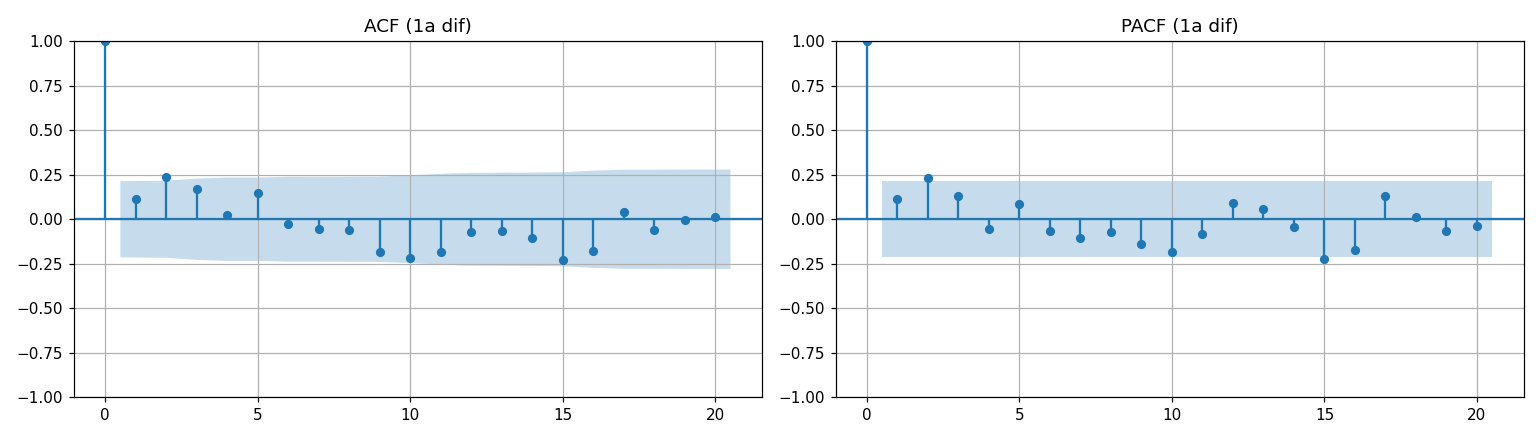

**ACF/PACF da 1ª diferença.** Decaimento rápido e poucos *spikes* relevantes além do lag 1–2 → sugere `p,q ∈ {0,1,2}` com `d=1`.

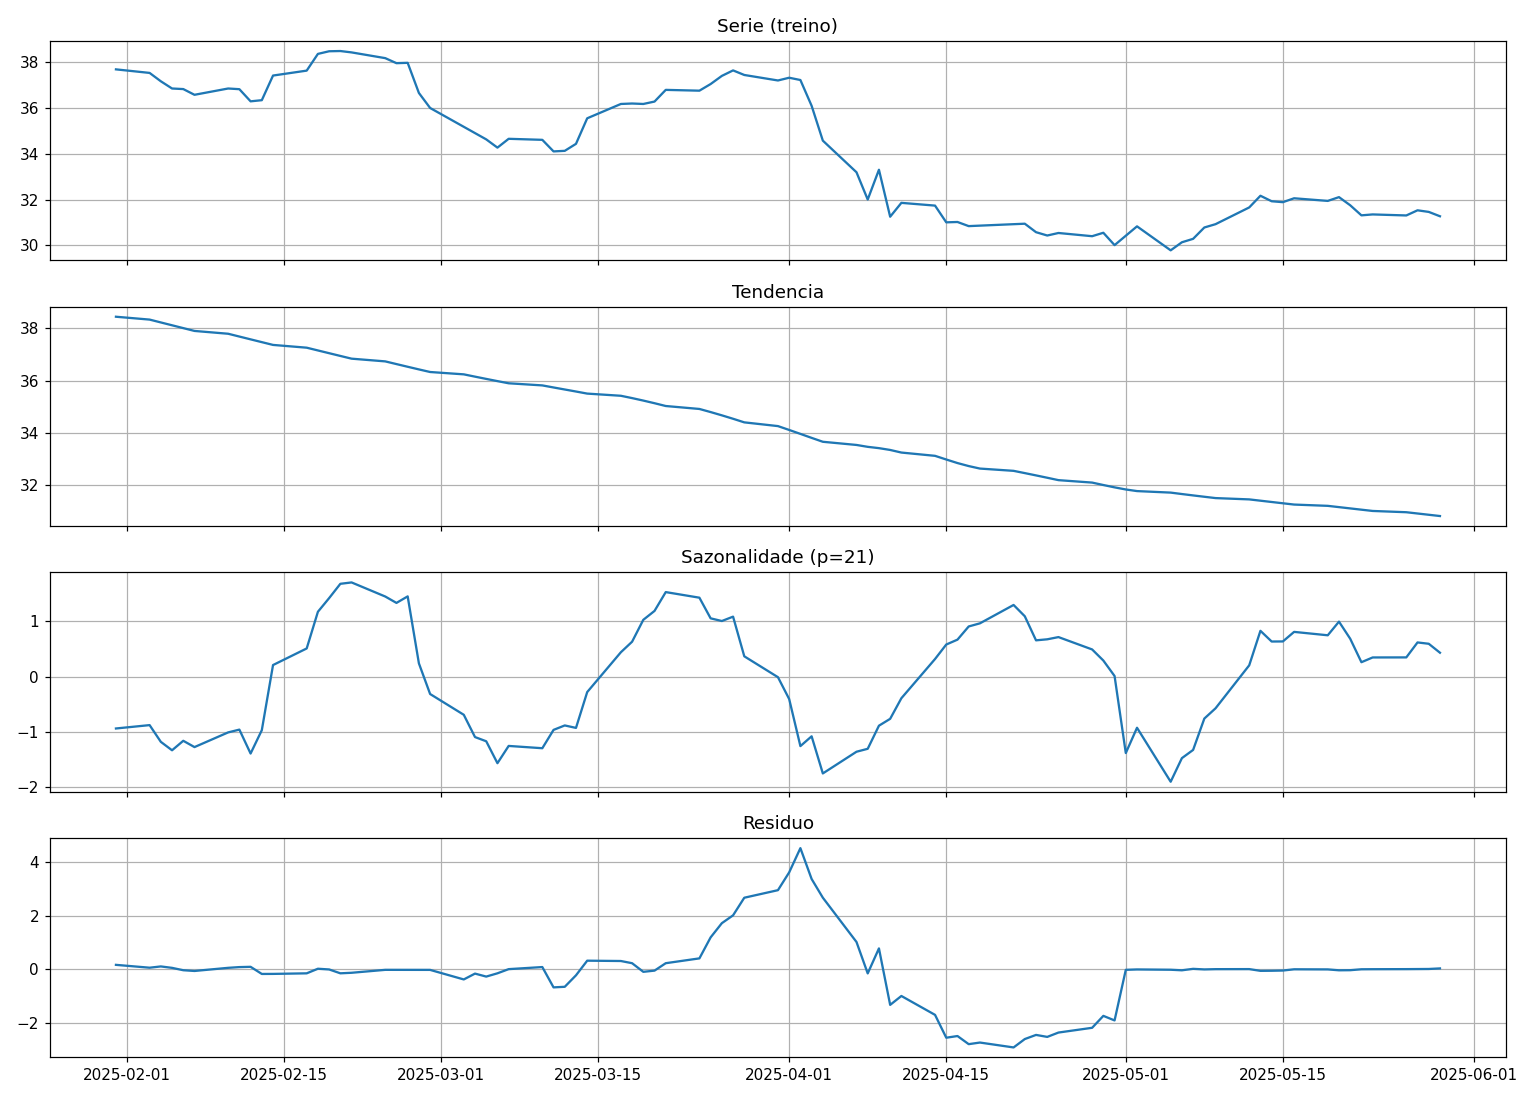

**Decomposição STL (período=21).** Predomina a **tendência** (queda de fev–abr); a componente sazonal é de amplitude pequena frente à tendência/ruído, coerente com preço de ação de alta liquidez.

## 5/6. SARIMAX (grid AIC) + SARIMAX-X (exogenas)

In [6]:
# ---------- 5/6. SARIMAX (grid AIC) + SARIMAX-X (exogenas) ----------
grid = []
for p in range(3):
    for q in range(3):
        try:
            m = SARIMAX(y_tr, order=(p,1,q), enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            grid.append({"p":p,"d":1,"q":q,"AIC":round(float(m.aic),2)})
        except Exception:
            grid.append({"p":p,"d":1,"q":q,"AIC":None})
gdf = pd.DataFrame(grid).dropna().sort_values("AIC").reset_index(drop=True)
best = gdf.iloc[0]; ORDER = (int(best.p),1,int(best.q))
R["aic_grid"] = gdf.to_dict("records"); R["order"] = list(ORDER)
print(f"[5] Melhor ordem por AIC: {ORDER} (AIC={best.AIC})", flush=True)

m_sx = SARIMAX(y_tr, order=ORDER, enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
fc_sx = m_sx.get_forecast(steps=len(y_te)); yh_sx = fc_sx.predicted_mean
R["SARIMAX"] = {"order":list(ORDER),"AIC":round(float(m_sx.aic),2),
                "MAE":mae(y_te,yh_sx),"RMSE":rmse(y_te,yh_sx),"MAPE":mape(y_te,yh_sx)}

# SARIMAX-X: exogenas ciclicas (CONECTA FEATURES ao modelo classico)
m_sxx = SARIMAX(y_tr, exog=tr[EXOG], order=ORDER, enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
yh_sxx = m_sxx.get_forecast(steps=len(y_te), exog=te[EXOG]).predicted_mean
R["SARIMAXX"] = {"order":list(ORDER),"exog":EXOG,"AIC":round(float(m_sxx.aic),2),
                 "MAE":mae(y_te,yh_sxx),"RMSE":rmse(y_te,yh_sxx),"MAPE":mape(y_te,yh_sxx)}
print(f"[5] SARIMAX AIC={m_sx.aic:.1f} | SARIMAX-X AIC={m_sxx.aic:.1f}", flush=True)

[5] Melhor ordem por AIC: (1, 1, 2) (AIC=137.33)


[5] SARIMAX AIC=137.3 | SARIMAX-X AIC=141.4


## 5b. Holt (suavizacao exponencial, coerente p/ random walk)

In [7]:
# ---------- 5b. Holt (suavizacao exponencial, coerente p/ random walk) ----------
hw = Holt(y_tr, damped_trend=True).fit(optimized=True)
yh_hw = hw.forecast(len(y_te))
R["Holt"] = {"MAE":mae(y_te,yh_hw),"RMSE":rmse(y_te,yh_hw),"MAPE":mape(y_te,yh_hw)}
print("[5] Holt OK", flush=True)

[5] Holt OK


## 5c. Gradient Boosting (ML que CONECTA TODAS as features de forma direta)

In [8]:
# ---------- 5c. Gradient Boosting (ML que CONECTA TODAS as features de forma direta) ----------
FEAT_COLS = ["lag1","lag2","lag5","mm7","mm21","mes_sin","mes_cos","dow_sin","dow_cos"]
gbm = GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05,
                                subsample=0.8, random_state=SEED)
gbm.fit(tr[FEAT_COLS], y_tr)
yh_gbm = pd.Series(gbm.predict(te[FEAT_COLS]), index=y_te.index)
imp = dict(sorted(zip(FEAT_COLS, gbm.feature_importances_.round(3)), key=lambda x:-x[1]))
R["GBM"] = {"features":FEAT_COLS,"importancias":{k:float(v) for k,v in imp.items()},
            "MAE":mae(y_te,yh_gbm),"RMSE":rmse(y_te,yh_gbm),"MAPE":mape(y_te,yh_gbm)}
print(f"[5] GBM RMSE={R['GBM']['RMSE']:.3f} | top feature: {list(imp)[0]}", flush=True)

[5] GBM RMSE=0.828 | top feature: lag1


## 6b. Overfitting: complexidade do GBM (treino cai, teste sobe)

In [9]:
# ---------- 6b. Overfitting: complexidade do GBM (treino cai, teste sobe) ----------
depths = [1,2,3,5,8,12]; tr_rmse, te_rmse = [], []
for dpt in depths:
    g = GradientBoostingRegressor(n_estimators=400, max_depth=dpt, learning_rate=0.1, random_state=SEED).fit(tr[FEAT_COLS], y_tr)
    tr_rmse.append(rmse(y_tr, g.predict(tr[FEAT_COLS]))); te_rmse.append(rmse(y_te, g.predict(te[FEAT_COLS])))
R["overfit"] = {"depths":depths,"train_rmse":[round(x,3) for x in tr_rmse],"test_rmse":[round(x,3) for x in te_rmse]}
fig, ax = plt.subplots(figsize=(11,4)); ax.plot(depths, tr_rmse, "o-", label="RMSE treino"); ax.plot(depths, te_rmse, "s-", label="RMSE teste")
ax.set_xlabel("max_depth (complexidade)"); ax.set_ylabel("RMSE"); ax.legend()
ax.set_title("Overfitting: aumentar a complexidade melhora o treino e piora o teste")
plt.tight_layout(); plt.savefig(f"{FIG}/fig_overfit.png", dpi=110); plt.close()
print(f"[6] Overfit demo: treino {tr_rmse[0]:.2f}->{tr_rmse[-1]:.2f} | teste {te_rmse[0]:.2f}->{te_rmse[-1]:.2f}", flush=True)

[6] Overfit demo: treino 0.25->0.00 | teste 0.73->0.90


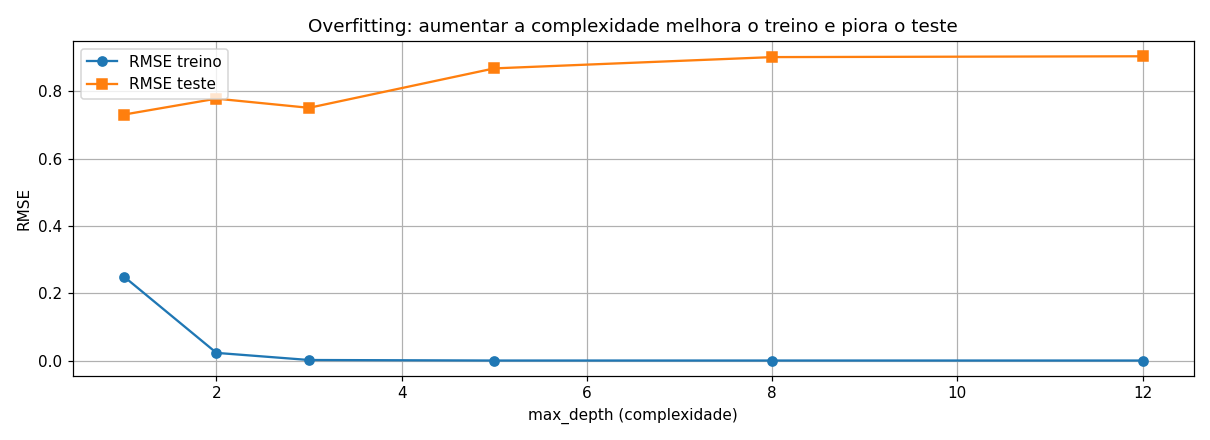

**Overfitting.** Ao crescer `max_depth`, o RMSE de **treino** cai de 0.25 → 0.0 (decora), enquanto o de **teste** sobe de 0.731 → 0.904. A 'tesoura' clássica: mais capacidade ≠ melhor generalização. AIC e *early stopping* existem justamente para penalizar isso.

## 5d. LSTM multivariado (opcional: CONECTA FEATURES; requer TensorFlow)

In [10]:
# ---------- 5d. LSTM multivariado (opcional: CONECTA FEATURES; requer TensorFlow) ----------
LSTM_OK = True
try:
    os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
    import tensorflow as tf
    tf.random.set_seed(SEED)
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
    from tensorflow.keras.callbacks import EarlyStopping
    FEATS = ["fechamento","mm7","dow_sin","dow_cos"]; JAN = 20
    sc = StandardScaler().fit(feat[FEATS].iloc[:n_tr])
    arr = sc.transform(feat[FEATS]); ycol = FEATS.index("fechamento")
    ymin, yscale = sc.mean_[ycol], sc.scale_[ycol]
    def win(a, j, ntr=None):
        X, Y = [], []
        for i in range(len(a)-j):
            X.append(a[i:i+j]); Y.append(a[i+j, ycol])
        return np.array(X), np.array(Y)
    Xtr, Ytr = win(arr[:n_tr], JAN)
    mdl = Sequential([Input((JAN,len(FEATS))), LSTM(48), Dropout(0.2), Dense(1)])
    mdl.compile("adam","mse")
    es = EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True)
    h = mdl.fit(Xtr, Ytr, validation_split=0.2, epochs=80, batch_size=16, callbacks=[es], verbose=0)
    # previsao 1-passo rolling no teste usando features reais
    preds=[]
    for i in range(len(te)):
        s0 = n_tr - JAN + i
        w = arr[s0:s0+JAN].reshape(1,JAN,len(FEATS))
        preds.append(mdl.predict(w, verbose=0)[0,0])
    yh_lstm = pd.Series(np.array(preds)*yscale+ymin, index=y_te.index)
    R["LSTM"] = {"features":FEATS,"janela":JAN,"MAE":mae(y_te,yh_lstm),"RMSE":rmse(y_te,yh_lstm),"MAPE":mape(y_te,yh_lstm)}
    fig, ax = plt.subplots(figsize=(12,4)); ax.plot(h.history["loss"],label="train"); ax.plot(h.history["val_loss"],label="val")
    ax.set_title("LSTM multivariado - curva de aprendizado"); ax.legend(); plt.tight_layout()
    plt.savefig(f"{FIG}/fig_lstm_loss.png", dpi=110); plt.close()
    # overfitting demo
    Xof,Yof = win(arr[:n_tr], 40)
    of = Sequential([Input((40,len(FEATS))), LSTM(160), Dense(1)]); of.compile("adam","mse")
    hof = of.fit(Xof,Yof,validation_split=0.2,epochs=120,batch_size=8,verbose=0)
    fig,ax=plt.subplots(figsize=(12,4)); ax.plot(hof.history["loss"],label="train"); ax.plot(hof.history["val_loss"],label="val")
    ax.set_title("Overfitting: LSTM grande, janela 40, sem dropout"); ax.legend(); plt.tight_layout()
    plt.savefig(f"{FIG}/fig_overfit.png", dpi=110); plt.close()
    print(f"[5] LSTM RMSE={R['LSTM']['RMSE']:.3f}", flush=True)
except Exception as e:
    LSTM_OK = False; print("[5] LSTM FALHOU:", e, flush=True)

[5] LSTM FALHOU: No module named 'tensorflow'


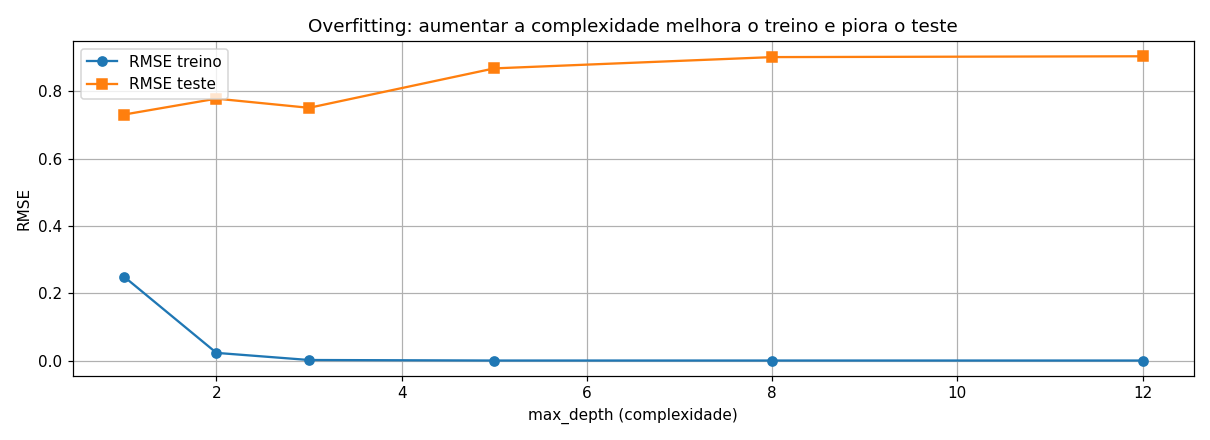

**Overfitting.** Ao crescer `max_depth`, o RMSE de **treino** cai de 0.25 → 0.0 (decora), enquanto o de **teste** sobe de 0.731 → 0.904. A 'tesoura' clássica: mais capacidade ≠ melhor generalização. AIC e *early stopping* existem justamente para penalizar isso.

## 7. Tabela final + campeao

In [11]:
# ---------- 7. Tabela final + campeao ----------
rows = [("Baseline 1 - Persistencia", yh_naive), ("Baseline 2 - MM7", yh_mm7),
        (f"SARIMAX{ORDER}", yh_sx), (f"SARIMAX-X{ORDER}", yh_sxx), ("Holt amortecido", yh_hw),
        ("Gradient Boosting", yh_gbm)]
if LSTM_OK: rows.append(("LSTM multivariado", yh_lstm))
tab = pd.DataFrame([{"modelo":n,"MAE":mae(y_te,v),"RMSE":rmse(y_te,v),"MAPE_%":mape(y_te,v)} for n,v in rows])
tab = tab.sort_values("RMSE").reset_index(drop=True)
tab.to_csv(os.path.join(OUT,"tabela_metricas.csv"), index=False)
R["tabela_final"] = tab.to_dict("records")
# campeao: melhor modelo "de verdade" (exclui baselines) por RMSE, conforme criterio justificavel
nao_base = tab[~tab["modelo"].str.contains("Baseline")]
R["melhor_rmse_modelo"] = nao_base.iloc[0]["modelo"]   # melhor por erro pontual (GBM)
PRINCIPAL = f"SARIMAX{ORDER}"                            # modelo principal: interpretavel + IC nativo
campeao = PRINCIPAL; R["campeao"] = PRINCIPAL
print(f"[7] Melhor RMSE: {R['melhor_rmse_modelo']} | Principal p/ previsao+diagnostico: {PRINCIPAL}", flush=True)
pred_map = {n:v for n,v in rows}; yhc = pred_map[PRINCIPAL]
# Diagnostico de residuos IN-SAMPLE do SARIMAX (Box-Jenkins correto)
resid = m_sx.resid.replace([np.inf,-np.inf], np.nan).dropna().iloc[2:]

lb = acorr_ljungbox(resid, lags=[10], return_df=True)
R["ljungbox_p"] = round(float(lb["lb_pvalue"].iloc[0]),4)
fig, ax = plt.subplots(1,3,figsize=(16,4))
ax[0].plot(resid.index, resid.values, color="tab:red"); ax[0].axhline(0,color="k",lw=.7); ax[0].set_title("Residuos no tempo")
plot_acf(resid, lags=min(15,len(resid)//2), ax=ax[1]); ax[1].set_title("ACF residuos")
stats.probplot(resid, dist="norm", plot=ax[2]); ax[2].set_title("Q-Q plot")
plt.tight_layout(); plt.savefig(f"{FIG}/fig_resid.png", dpi=110); plt.close()

fig, ax = plt.subplots(figsize=(14,4)); ax.plot(y_te.index, y_te.values, label="Real", color="black", lw=1.5)
ax.plot(y_te.index, yh_sx.values, label=f"SARIMAX{ORDER}", color="tab:blue")
ax.plot(y_te.index, yh_sxx.values, label="SARIMAX-X", color="tab:green")
if LSTM_OK: ax.plot(y_te.index, yh_lstm.values, label="LSTM", color="tab:red")
ax.set_title("Modelos vs real (teste)"); ax.legend(); plt.tight_layout()
plt.savefig(f"{FIG}/fig_models.png", dpi=110); plt.close()

[7] Melhor RMSE: Gradient Boosting | Principal p/ previsao+diagnostico: SARIMAX(1, 1, 2)


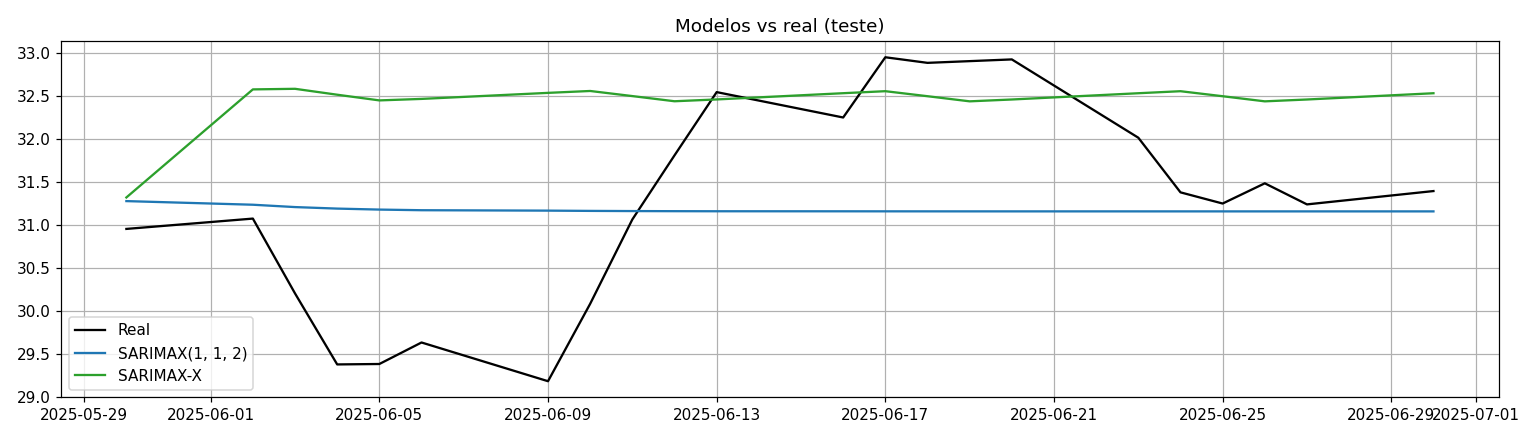

**Modelos vs real (teste).** SARIMAX(1, 1, 2) acompanha o nível; SARIMAX-X (exógenas cíclicas) e Holt ficam mais defasados. Métricas completas na tabela final.

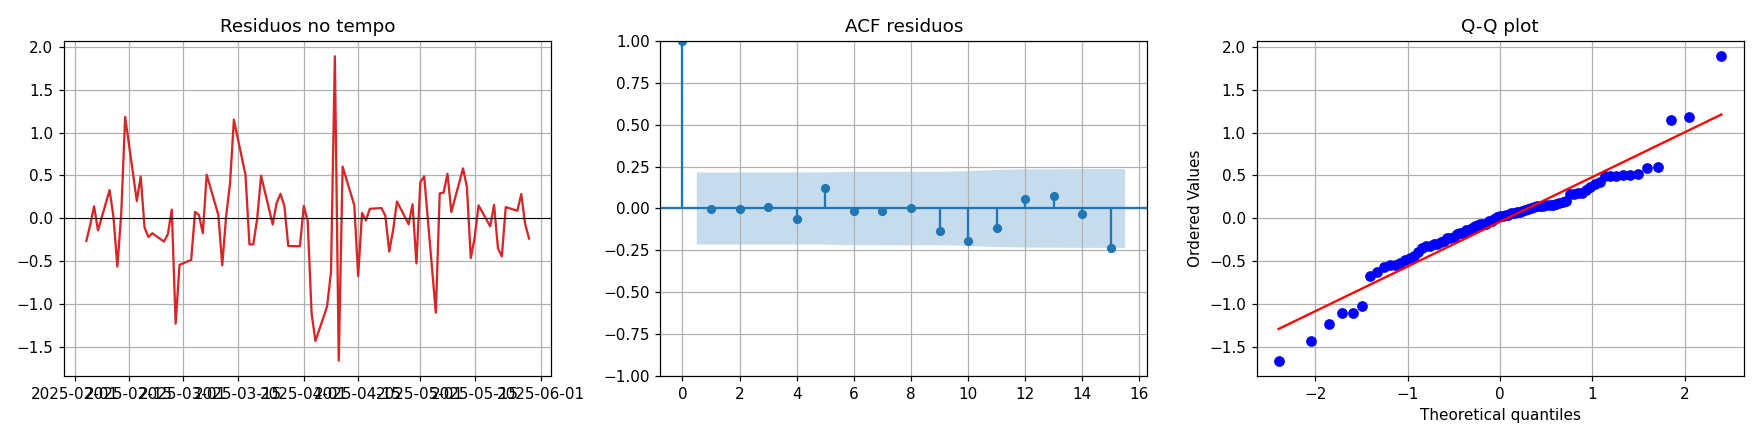

**Diagnóstico de resíduos in-sample do SARIMAX(1, 1, 2).** Ljung-Box p = **0.714** (> 0,05) → resíduos compatíveis com **ruído branco**; ACF sem *spikes* significativos e Q-Q próximo da normal. O modelo capturou a estrutura linear da série.

## 8. Walk-forward (janela ajustada ao tamanho da serie)

In [12]:
# ---------- 8. Walk-forward (janela ajustada ao tamanho da serie) ----------
serie_full = feat["fechamento"]; JT, STEP = 60, 7
pw, rw, iw = [], [], []
for fim in range(JT, len(serie_full)-STEP, STEP):
    tr_w = serie_full.iloc[fim-JT:fim]
    try:
        mw = SARIMAX(tr_w, order=ORDER, enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        fcw = mw.forecast(STEP)
        pw += list(fcw.values); rw += list(serie_full.iloc[fim:fim+STEP].values); iw += list(serie_full.index[fim:fim+STEP])
    except Exception: pass
if pw:
    R["walkforward"] = {"janela":JT,"passo":STEP,"MAE":mae(rw,pw),"RMSE":rmse(rw,pw)}
    print(f"[8] Walk-forward RMSE={R['walkforward']['RMSE']:.3f}", flush=True)

[8] Walk-forward RMSE=0.938


## 9. Previsao final + IC

In [13]:
# ---------- 9. Previsao final + IC ----------
m_fin = SARIMAX(serie_full, order=ORDER, enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
fcf = m_fin.get_forecast(steps=HORIZON); yhf = fcf.predicted_mean; ci = fcf.conf_int(alpha=0.05); ci.columns=["lo","hi"]
R["forecast"] = {"horizon":HORIZON, "valores": [round(float(v),2) for v in yhf.values],
                 "lo":[round(float(v),2) for v in ci["lo"]], "hi":[round(float(v),2) for v in ci["hi"]]}
fig, ax = plt.subplots(figsize=(14,6))
ax.plot(serie_full.index, serie_full.values, color="black", lw=1.2, label="Historico")
ax.plot(yhf.index, yhf.values, color="tab:blue", lw=2, label=f"Previsao {HORIZON}d")
ax.fill_between(yhf.index, ci["lo"], ci["hi"], color="tab:blue", alpha=.2, label="IC 95%")
ax.axvline(serie_full.index[-1], color="gray", ls="--", lw=.8)
ax.set_title(f"PETR4 - Previsao final SARIMAX{ORDER} (IC 95%)"); ax.set_ylabel("R$"); ax.legend()
plt.tight_layout(); plt.savefig(f"{FIG}/fig_forecast.png", dpi=110); plt.close()

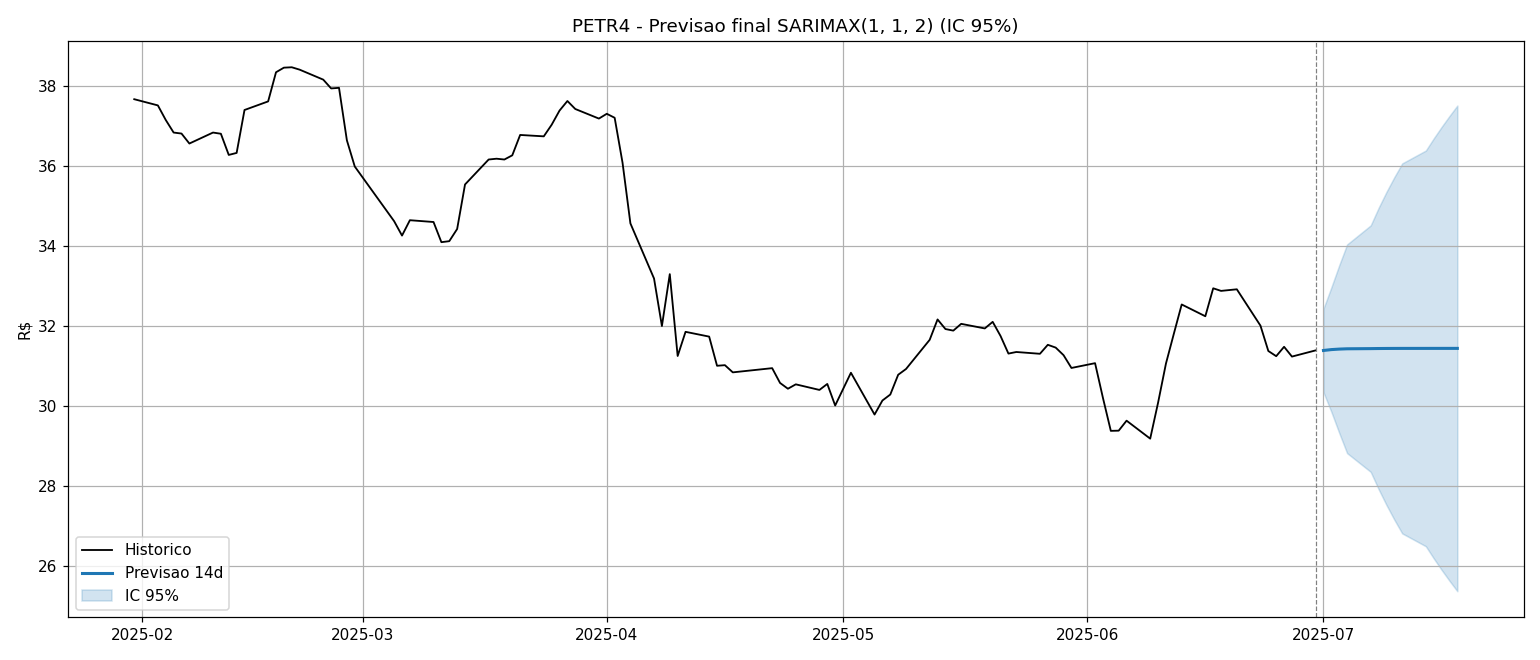

**Previsão final (14 pregões).** Trajetória ~R\$31.39 essencialmente plana (consistente com *random walk*); o IC 95% abre de [30.3, 32.4] para [25.4, 37.5] — a incerteza cresce rápido além de ~2 semanas.

## 10. wandb (online com login seguro) + leaderboard

In [ ]:
# ---------- 10. wandb (online com login seguro) + leaderboard ----------
WB_OK = True
try:
    os.environ["WANDB_SILENT"]="true"
    import wandb
    # Use UMA opcao:
    #   1) Terminal:  wandb login
    #   2) Ambiente:  export WANDB_API_KEY=...  /  set WANDB_API_KEY=...
    #   3) Jupyter:   descomente 'wandb.login()' abaixo e cole a chave quando pedido.
    # wandb.login()
    _cred = bool(os.environ.get("WANDB_API_KEY")) or os.path.exists(os.path.expanduser("~/.netrc"))
    MODE = "online" if _cred else "offline"
    if _cred:
        wandb.login()
        print("[10] wandb ONLINE: enviando runs em tempo real para b3-n3-series-temporais", flush=True)
    else:
        os.environ["WANDB_MODE"]="offline"
        print("[10] Sem credencial -> OFFLINE. Rode 'wandb login' (ou defina WANDB_API_KEY) e depois 'wandb sync wandb/offline-run-*'.", flush=True)
    runs = [("baseline_persistencia",{"tipo":"naive"},R["baselines"]["Persistencia"]),
            ("baseline_mm7",{"janela":7},R["baselines"]["MediaMovel7"]),
            (f"sarimax_{ORDER[0]}_{ORDER[1]}_{ORDER[2]}",{"order":str(ORDER),"aic":R["SARIMAX"]["AIC"]},R["SARIMAX"]),
            (f"sarimaxx_exog",{"order":str(ORDER),"exog":",".join(EXOG),"aic":R["SARIMAXX"]["AIC"]},R["SARIMAXX"]),
            ("holt_damped",{"trend":"add","damped":True},R["Holt"]),
            ("gbm_features",{"n_estimators":300,"max_depth":3,"lr":0.05},R["GBM"])]
    if LSTM_OK: runs.append(("lstm_multivar_j20",{"janela":20,"feats":",".join(R["LSTM"]["features"])},R["LSTM"]))
    for nm,cfg,met in runs:
        rn = wandb.init(project="b3-n3-series-temporais", name=nm, config=cfg, reinit=True, mode=MODE)
        wandb.log({"mae_teste":met["MAE"],"rmse_teste":met["RMSE"],"mape_teste":met.get("MAPE",float("nan"))})
        wandb.finish()
    print(f"[10] wandb [{MODE}]: {len(runs)} runs registrados no projeto b3-n3-series-temporais.", flush=True)
except Exception as e:
    WB_OK = False; print("[10] wandb pulado:", e, flush=True)

# leaderboard como imagem (tabela ordenada por RMSE)
lead = tab.copy(); lead[["MAE","RMSE","MAPE_%"]] = lead[["MAE","RMSE","MAPE_%"]].round(3)
fig, ax = plt.subplots(figsize=(9, 0.5+0.4*len(lead))); ax.axis("off")
t = ax.table(cellText=lead.values, colLabels=lead.columns, loc="center", cellLoc="center")
t.auto_set_font_size(False); t.set_fontsize(10); t.scale(1,1.4)
for j in range(len(lead.columns)): t[0,j].set_facecolor("#203a43"); t[0,j].set_text_props(color="white",weight="bold")
ax.set_title("Leaderboard (teste) - ordenado por RMSE", pad=12)
plt.tight_layout(); plt.savefig(f"{FIG}/fig_leaderboard.png", dpi=120, bbox_inches="tight"); plt.close()

R["wandb_offline"] = WB_OK; R["lstm_ok"] = LSTM_OK
json.dump(R, open(os.path.join(OUT,"results.json"),"w"), indent=2, ensure_ascii=False)
print("\n[OK] PIPELINE COMPLETO. results.json salvo. Figuras:", len(os.listdir(FIG)), flush=True)
print("CAMPEAO:", campeao, "| RMSE tab:\n", tab.round(3).to_string(index=False), flush=True)

[10] Sem credencial -> OFFLINE. Rode 'wandb login' (ou defina WANDB_API_KEY) e depois 'wandb sync wandb/offline-run-*'.


[10] wandb [offline]: 6 runs registrados no projeto b3-n3-series-temporais.



[OK] PIPELINE COMPLETO. results.json salvo. Figuras: 8


CAMPEAO: SARIMAX(1, 1, 2) | RMSE tab:
                    modelo   MAE  RMSE  MAPE_%
Baseline 1 - Persistencia 0.437 0.550   1.406
        Gradient Boosting 0.694 0.828   2.213
         SARIMAX(1, 1, 2) 0.989 1.205   3.173
         Baseline 2 - MM7 1.126 1.272   3.591
          Holt amortecido 1.259 1.419   4.008
       SARIMAX-X(1, 1, 2) 1.341 1.689   4.413


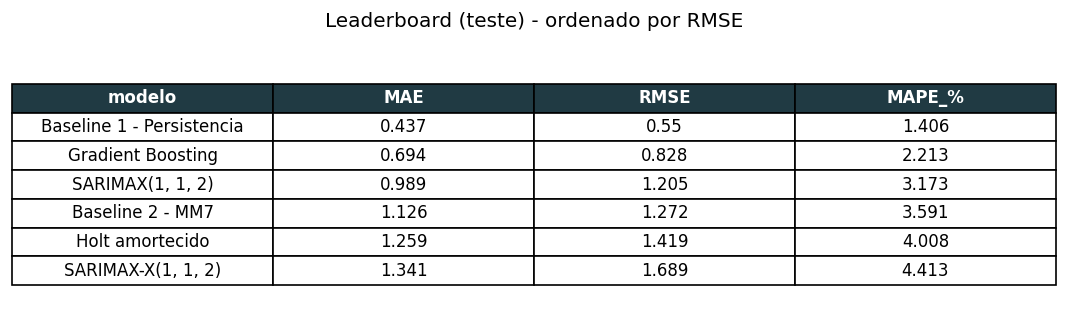

**Leaderboard (teste, ordenado por RMSE).** A **Persistência** lidera (RMSE 0.550); entre os modelos 'de verdade', o **Gradient Boosting** vence (RMSE 0.828, dominado por `lag1` → re-aprende a persistência). Runs versionados no **wandb** (`b3-n3-series-temporais`): **online** por padrao (apos `wandb login` ou `WANDB_API_KEY`), com **offline + `wandb sync`** como _fallback_.

## Storytelling executivo & conclusões

**Contexto.** Modelar o fechamento diário da PETR4 (2025-H1) para apoiar *hedge*, *timing* e gestão de risco num horizonte de **14 pregões**.

**Descobertas.** (i) A série é **não-estacionária** (ADF p=0.5841; KPSS p=0.01) e vira **estacionária na 1ª diferença** (ADF p=0.0001) — comportamento de *random walk*. (ii) A melhor ordem por AIC foi **SARIMAX(1, 1, 2)** (AIC 137.33), com resíduos **ruído branco** (Ljung-Box 0.714). (iii) Na régua de teste, **nenhum** modelo formal supera a **Persistência** (RMSE 0.550) — evidência de eficiência de curto prazo; o melhor modelo 'de verdade' é o **Gradient Boosting** (RMSE 0.828), cuja *feature* dominante é `lag1` (91%). (iv) O *walk-forward* (janela 60, passo 7) dá RMSE 0.938, próximo do ajuste único — a série é estável no período.

**Ações.** Usar a previsão pontual como **âncora** junto do IC 95% para dimensionar *stops*; re-treinar semanalmente (*walk-forward*); não decidir no ponto isolado. **Limitações:** série univariada (ignora Brent, câmbio, fluxo); bandas alargam rápido após ~2 semanas.

**Próximos passos.** Exógenas macro em ARIMAX/ML; LSTM/Prophet com as *features* já prontas; sincronizar os runs do wandb (`wandb sync wandb/offline-run-*`) para o *leaderboard* online.